In [7]:
import numpy as np
import matplotlib.pyplot as plt
import allantools as at
import pandas as pd
from pyparsing import lineEnd

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Palatino Linotype', 'URW Palladio L', 'Georgia'],
})

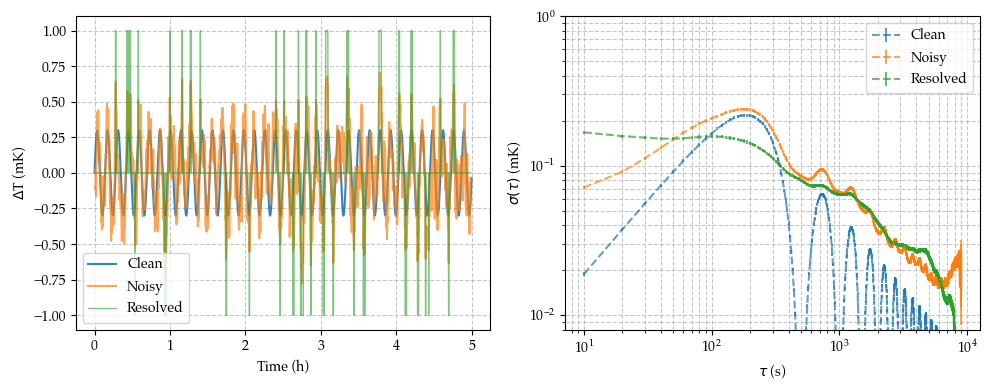

In [8]:
df = pd.DataFrame()

rate = 1 / 10

df['time_s'] = np.arange(0, 5 * 3600, 1/rate)  # 30 seconds with 1 ms intervals
df['time_h'] = df['time_s'] / 3600

freq_h = 0.8
freq_s = 1/500

df['signal_clean'] = 0.3 * np.sin(2 * np.pi * freq_s * df['time_s']) # 0.8

# Add Gaussian noise
df['signal_noisy'] = np.random.normal(df['signal_clean'], 0.6, len(df)) # 0.13

# Readout resolution at 0.01
averaging = True
if averaging:
    df['signal_noisy'] = df['signal_noisy'].rolling(window=9, center=True).mean()
    df['signal_noisy_resolved'] = np.round(df['signal_noisy'], decimals=0)
else:
    df['signal_noisy_resolved'] = np.round(df['signal_noisy'], decimals=0)


taus_clean, adev_clean, err_clean, _ = at.oadev(data=df['signal_clean'], rate=rate, taus='all', data_type='freq')
taus, adev, err, _ = at.oadev(data=df['signal_noisy'], rate=rate, taus='all', data_type='freq')
taus_res, adev_res, err_res, _ = at.oadev(data=df['signal_noisy_resolved'], rate=rate, taus='all', data_type='freq')

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
ax1 = plt.subplot(1,2,1)
ax1.plot(df['time_h'], df['signal_clean'], label='Clean', alpha=0.9)
ax1.plot(df['time_h'], df['signal_noisy'], label='Noisy', alpha=0.7)
ax1.plot(df['time_h'], df['signal_noisy_resolved'], label='Resolved', alpha=0.6, linewidth=1)
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'$\Delta$T (mK)')
ax1.legend()
ax1.grid(which='both', linestyle='--', alpha=0.7)

ax2 = plt.subplot(1,2,2)
ax2.errorbar(taus_clean, adev_clean, yerr=err_clean, label='Clean', alpha=0.7, fmt="--", color='tab:blue')
ax2.errorbar(taus, adev, yerr=err, label='Noisy', alpha=0.7, fmt="--", color='tab:orange')
ax2.errorbar(taus_res, adev_res, yerr=err_res, label='Resolved', alpha=0.7, fmt="--", color='tab:green')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'$\tau$ (s)')
ax2.set_ylabel(r'$\sigma(\tau)$ (mK)')
ax2.set_ylim(8e-3, 1e0)
ax2.legend()
ax2.grid(which='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


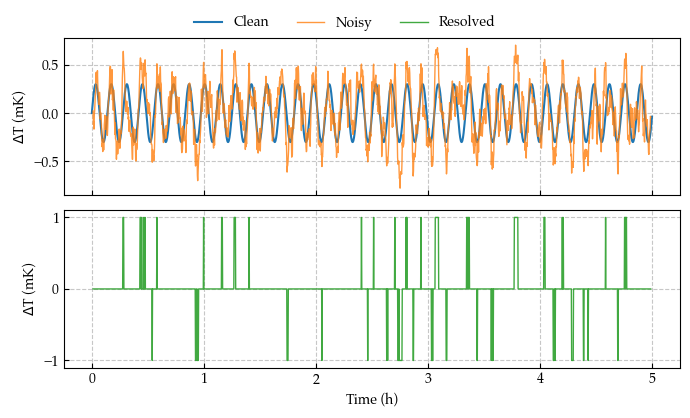

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

ax1.plot(df['time_h'], df['signal_clean'], label='Clean', alpha=1, color='tab:blue')
ax1.plot(df['time_h'], df['signal_noisy'], label='Noisy', alpha=0.8, linewidth=1, color='tab:orange')
ax1.set_ylabel(r'$\Delta$T (mK)')
ax1.tick_params(axis='both', which='both', direction='in')
ax1.grid(which='both', linestyle='--', alpha=0.7)

ax2.plot(df['time_h'], df['signal_noisy_resolved'], label='Resolved', alpha=0.9, linewidth=1, color='tab:green')
ax2.set_xlabel('Time (h)')
ax2.set_ylabel(r'$\Delta$T (mK)')
ax2.set_ylim(-1.1, 1.1)
ax2.set_yticks(np.arange(-1, 2, 1))
ax2.tick_params(axis='both', which='both', direction='in')
ax2.grid(which='both', linestyle='--', alpha=0.7)

handles, labels = [], []
for ax in (ax1, ax2):
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels += l

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=len(labels), frameon=False)
plt.tight_layout()
plt.savefig(f'fig/sim_temp_ts.pdf', dpi=600, bbox_inches='tight')
plt.show()

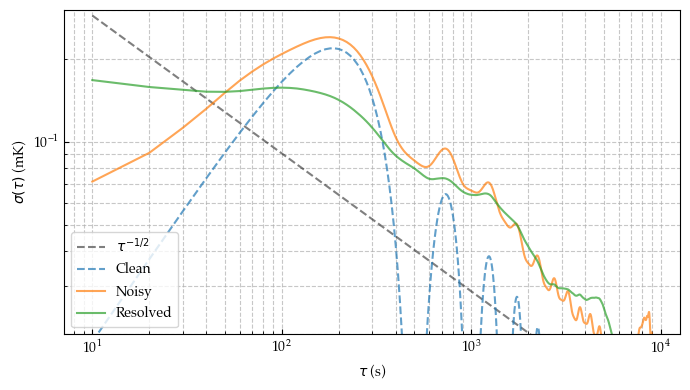

In [10]:
plt.figure(figsize=(7, 4))
plt.errorbar(taus_clean, adev_clean, label='Clean', alpha=0.7, fmt="--", color='tab:blue')
plt.errorbar(taus, adev, label='Noisy', alpha=0.7, fmt="-", color='tab:orange')
plt.errorbar(taus_res, adev_res, label='Resolved', alpha=0.7, fmt="-", color='tab:green')

t = np.logspace(np.log10(taus[0]), np.log10(taus[-1]), 100)
f = lambda t, a: t**(0.5 * a)

slope = -1
scale = adev[0]*4 / f(taus[0], slope)
plt.plot(t, scale * f(t, slope), 'k--', alpha=0.5, label=r'$\tau^{-1/2}$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma(\tau)$ (mK)')
plt.ylim(2e-2, 3e-1)
plt.tick_params(axis='both', which='both', direction='in')
plt.legend(loc='lower left')
plt.grid(which='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'fig/sim_temp_adev.pdf', dpi=600)
plt.show()

In [11]:
import datetime
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
df.to_csv(f'data/simulated_temp_data_{timestamp}.csv', index=False)